# 2D Ising Model (50x50) with Periodic Boundary Conditions

Parameters used:
- Lattice size: $50\times50$
- $J=1$
- $k_B=1$
- $T=1$
- Hamiltonian: $H=-J\sum_{\langle i,j\rangle} s_i s_j$

Update rule (Metropolis):
- Compute $\Delta H = H_{\text{new}} - H_{\text{old}}$ for a proposed spin flip.
- If $\Delta H \le 0$, accept.
- Else, accept if $e^{-\beta\Delta H} \ge x$, where $x\sim U(0,1)$ and $\beta=1/(k_B T)$.

The plot below shows energy $H$ versus accepted step number.

In [2]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


Accepted steps: 5000, Proposed steps: 23648
Final energy H: -3924.0


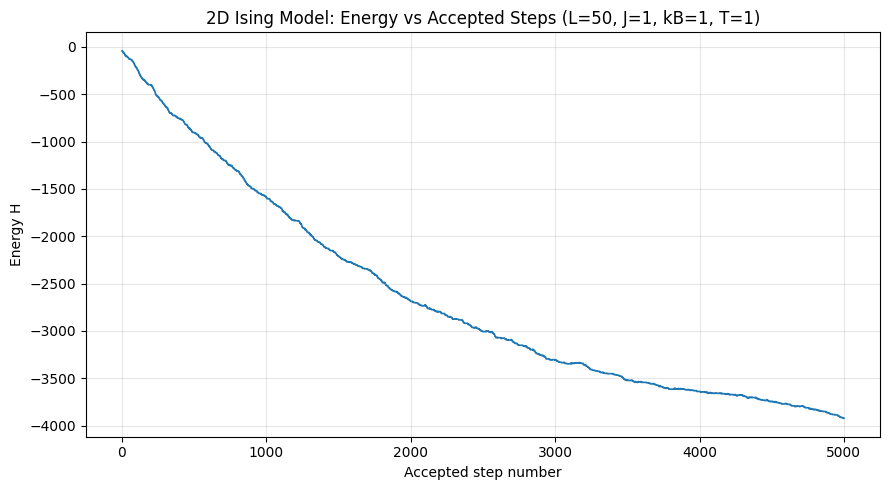

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Model parameters
# -----------------------------
L = 50
J = 1.0
k_B = 1.0
T = 1.0
beta = 1.0 / (k_B * T)

# Number of accepted configurations to record
target_accepted_steps = 5000

# Random initial spin configuration (+1 or -1)
rng = np.random.default_rng(seed=42)
spins = rng.choice([-1, 1], size=(L, L))


def total_energy(config, J=1.0):
    """Compute H = -J * sum_{<i,j>} s_i s_j with periodic boundaries."""
    # Count right and down neighbors only to avoid double counting
    right = np.roll(config, shift=-1, axis=1)
    down = np.roll(config, shift=-1, axis=0)
    return -J * np.sum(config * (right + down))


def delta_energy_if_flip(config, i, j, J=1.0):
    """Energy change for flipping one spin at (i, j) with periodic boundaries."""
    s = config[i, j]
    nn_sum = (
        config[(i + 1) % L, j]
        + config[(i - 1) % L, j]
        + config[i, (j + 1) % L]
        + config[i, (j - 1) % L]
    )
    # Standard Ising single-spin flip energy difference
    return 2.0 * J * s * nn_sum


# Initial energy
H_current = total_energy(spins, J=J)
accepted_steps = []
accepted_energies = []

accepted_count = 0
proposed_count = 0

# Keep proposing flips until target number of accepted moves is reached
while accepted_count < target_accepted_steps:
    proposed_count += 1

    i = rng.integers(0, L)
    j = rng.integers(0, L)

    dH = delta_energy_if_flip(spins, i, j, J=J)

    # Metropolis criterion
    if dH <= 0 or rng.random() < np.exp(-beta * dH):
        spins[i, j] *= -1
        H_current += dH
        accepted_count += 1

        accepted_steps.append(accepted_count)
        accepted_energies.append(H_current)

print(f"Accepted steps: {accepted_count}, Proposed steps: {proposed_count}")
print(f"Final energy H: {H_current}")

# Plot H vs accepted step number
plt.figure(figsize=(9, 5))
plt.plot(accepted_steps, accepted_energies, lw=1.2)
plt.xlabel("Accepted step number")
plt.ylabel("Energy H")
plt.title("2D Ising Model: Energy vs Accepted Steps (L=50, J=1, kB=1, T=1)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Magnetization Analysis at Fixed Temperature

For each accepted Metropolis update, magnetization is

$$
M = \sum_i s_i
$$

At fixed temperature ($T=1$ here), we record $M$ versus accepted step number.

We also compute:

$$
\langle M \rangle = \frac{1}{N_s}\sum_{k=1}^{N_s} M_k
$$

$$
\langle M^2 \rangle = \frac{1}{N_s}\sum_{k=1}^{N_s} M_k^2
$$

$$
\mathrm{Var}(M)=\langle M^2\rangle-\langle M\rangle^2
$$

As requested, we take magnetic susceptibility as:

$$
\chi = \mathrm{Var}(M)
$$

At T=1.0:
<M> = 132.818400
<M^2> = 24381.612800
Variance = <M^2>-<M>^2 = 6740.885421
chi (susceptibility) = 6740.885421


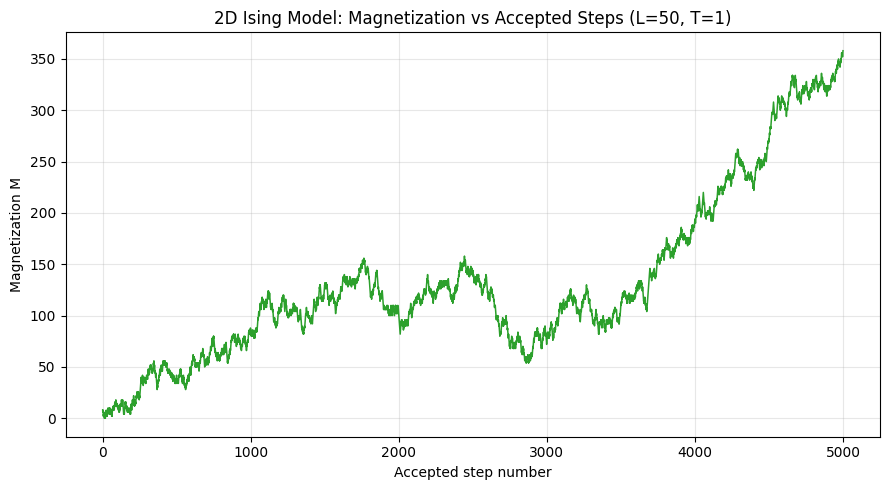

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed-temperature run for M vs accepted step number
L = 50
J = 1.0
k_B = 1.0
T = 1.0
beta = 1.0 / (k_B * T)

target_accepted_steps_M = 5000
rng = np.random.default_rng(seed=(42, 99))  

spins_M = rng.choice([-1, 1], size=(L, L))
M_current = int(np.sum(spins_M))

accepted_steps_M = []
accepted_M = []
accepted_count_M = 0

while accepted_count_M < target_accepted_steps_M:
    i = rng.integers(0, L)
    j = rng.integers(0, L)

    s = spins_M[i, j]
    nn_sum = (
        spins_M[(i + 1) % L, j]
        + spins_M[(i - 1) % L, j]
        + spins_M[i, (j + 1) % L]
        + spins_M[i, (j - 1) % L]
    )
    dH = 2.0 * J * s * nn_sum

    if dH <= 0 or rng.random() < np.exp(-beta * dH):
        spins_M[i, j] = -s
        M_current -= 2 * s

        accepted_count_M += 1
        accepted_steps_M.append(accepted_count_M)
        accepted_M.append(M_current)

M_arr = np.array(accepted_M, dtype=float)
M_avg = float(np.mean(M_arr))
M2_avg = float(np.mean(M_arr**2))
variance_M = M2_avg - M_avg**2
chi = variance_M

print(f"At T={T}:")
print(f"<M> = {M_avg:.6f}")
print(f"<M^2> = {M2_avg:.6f}")
print(f"Variance = <M^2>-<M>^2 = {variance_M:.6f}")
print(f"chi (susceptibility) = {chi:.6f}")

plt.figure(figsize=(9, 5))
plt.plot(accepted_steps_M, accepted_M, lw=1.1, color="tab:green")
plt.xlabel("Accepted step number")
plt.ylabel("Magnetization M")
plt.title("2D Ising Model: Magnetization vs Accepted Steps (L=50, T=1)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Sweep: \(\chi(T)\) and \(\langle M\rangle(T)\)

Now we repeat the simulation over a range of temperatures and compute:

- $\langle M\rangle(T)$
- $\chi(T)=\langle M^2\rangle-\langle M\rangle^2$

using accepted Metropolis updates with periodic boundary conditions.

Temperature sweep complete.
Columns: T, <M>, chi
 0.80    272.4140    11318.1566
 1.00   -368.2750    15751.3764
 1.20   -198.6130     1361.0362
 1.40   -157.4940     3596.1760
 1.60   -354.6200     8351.9076
 1.80   -119.4750      651.5124
 2.00     46.3030     1067.3882
 2.20    -29.5590     3321.5775
 2.40    -31.0670      682.2295
 2.60     79.1390      459.6507
 2.80     83.3450      607.0910
 3.00      1.9240     1844.8622
 3.20    101.5680     3336.1774
 3.40     77.1400     1853.6924
 3.60     50.7970     1894.6208
 3.80     73.2520     3892.3005
 4.00     48.1980     5752.6648


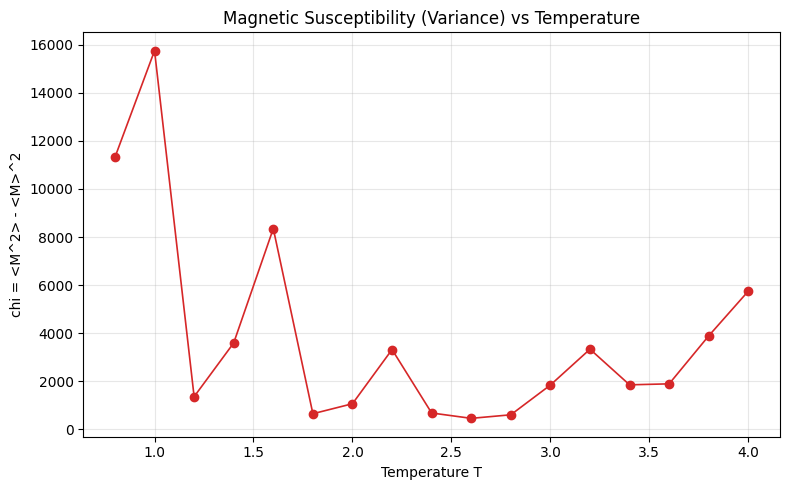

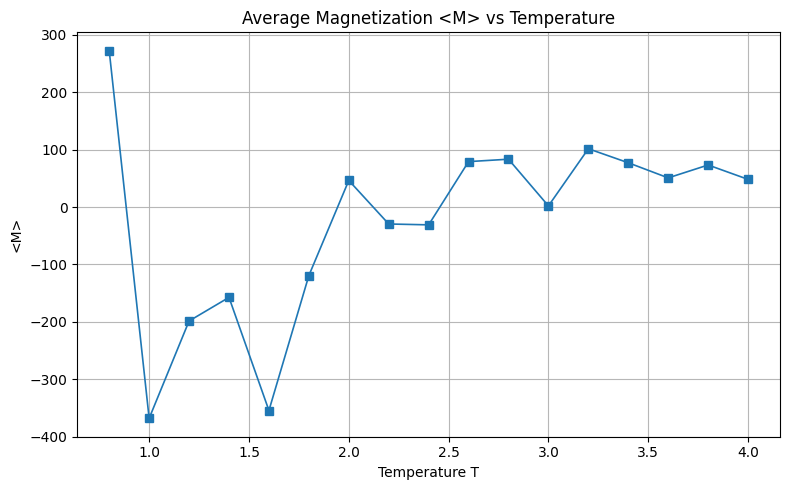

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = 50
J = 1.0
k_B = 1.0

T_values = np.linspace(0.8, 4.0, 17)

def run_magnetization_stats(L, J, k_B, T, equil_accepted=2000, meas_accepted=4000, seed=0):
    """Return <M>, <M^2>, and chi=<M^2>-<M>^2 at a given T."""
    rng = np.random.default_rng(seed)
    beta = 1.0 / (k_B * T)

    spins = rng.choice([-1, 1], size=(L, L))
    M_current = int(np.sum(spins))

    accepted = 0
    M_samples = []

    target = equil_accepted + meas_accepted

    while accepted < target:
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        s = spins[i, j]
        nn_sum = (
            spins[(i + 1) % L, j]
            + spins[(i - 1) % L, j]
            + spins[i, (j + 1) % L]
            + spins[i, (j - 1) % L]
        )
        dH = 2.0 * J * s * nn_sum

        if dH <= 0 or rng.random() < np.exp(-beta * dH):
            spins[i, j] = -s
            M_current -= 2 * s
            accepted += 1

            if accepted > equil_accepted:
                M_samples.append(M_current)

    M_arr = np.array(M_samples, dtype=float)
    M_avg = float(np.mean(M_arr))
    M2_avg = float(np.mean(M_arr**2))
    chi_val = M2_avg - M_avg**2
    return M_avg, M2_avg, chi_val

M_avg_vs_T = []
chi_vs_T = []

for idx, T in enumerate(T_values):
    M_avg, M2_avg, chi_val = run_magnetization_stats(
        L=L,
        J=J,
        k_B=k_B,
        T=float(T),
        equil_accepted=2000,
        meas_accepted=4000,
        seed=1000 + idx,
    )
    M_avg_vs_T.append(M_avg)
    chi_vs_T.append(chi_val)

M_avg_vs_T = np.array(M_avg_vs_T)
chi_vs_T = np.array(chi_vs_T)

print("Temperature sweep complete.")
print("Columns: T, <M>, chi")
for T, M_avg, chi_val in zip(T_values, M_avg_vs_T, chi_vs_T):
    print(f"{T:5.2f}  {M_avg:10.4f}  {chi_val:12.4f}")


plt.figure(figsize=(8, 5))
plt.plot(T_values, chi_vs_T, marker="o", lw=1.2, color="tab:red")
plt.xlabel("Temperature T")
plt.ylabel("chi = <M^2> - <M>^2")
plt.title("Magnetic Susceptibility (Variance) vs Temperature")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(T_values, M_avg_vs_T, marker="s", lw=1.2, color="tab:blue")
plt.xlabel("Temperature T")
plt.ylabel("<M>")
plt.title("Average Magnetization <M> vs Temperature")
plt.grid(alpha=0.9)
plt.tight_layout()
plt.show()